# Heart Disease Prediction - Exploratory Data Analysis

**Summary:**

1. Dataset overview and quality
2. Target variable distribution
3. Demographic patterns (age, gender)
4. Clinical measurements (BP, cholesterol, HR)
5. Symptom indicators (chest pain, angina)
6. Feature relationships and correlations
7. Key insights and patterns

## Setup: Load Libraries and Data

In [ ]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

# Add src to path for imports
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

from visualization.plots import *

# Set data path (from raw folder)
DATA_PATH = ROOT / 'data' / 'raw' / 'heart.csv'
FIG_DIR = ROOT / 'results' / 'figures'

print(f"Root: {ROOT}")
print(f"Data: {DATA_PATH}")
print(f"Figures: {FIG_DIR}")

✓ Root: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction
✓ Data: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\data\raw\heart.csv
✓ Figures: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\figures


In [12]:
# Load data from raw folder
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} records, {df.shape[1]} features")
print(f"\nFirst 5 records:")
df.head()

Dataset loaded: 918 records, 12 features

First 5 records:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Dataset Overview

C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:25: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  ax.set_ylabel("Count")
C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:26: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  _save_figure(fig, output_dir, filename)
c:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


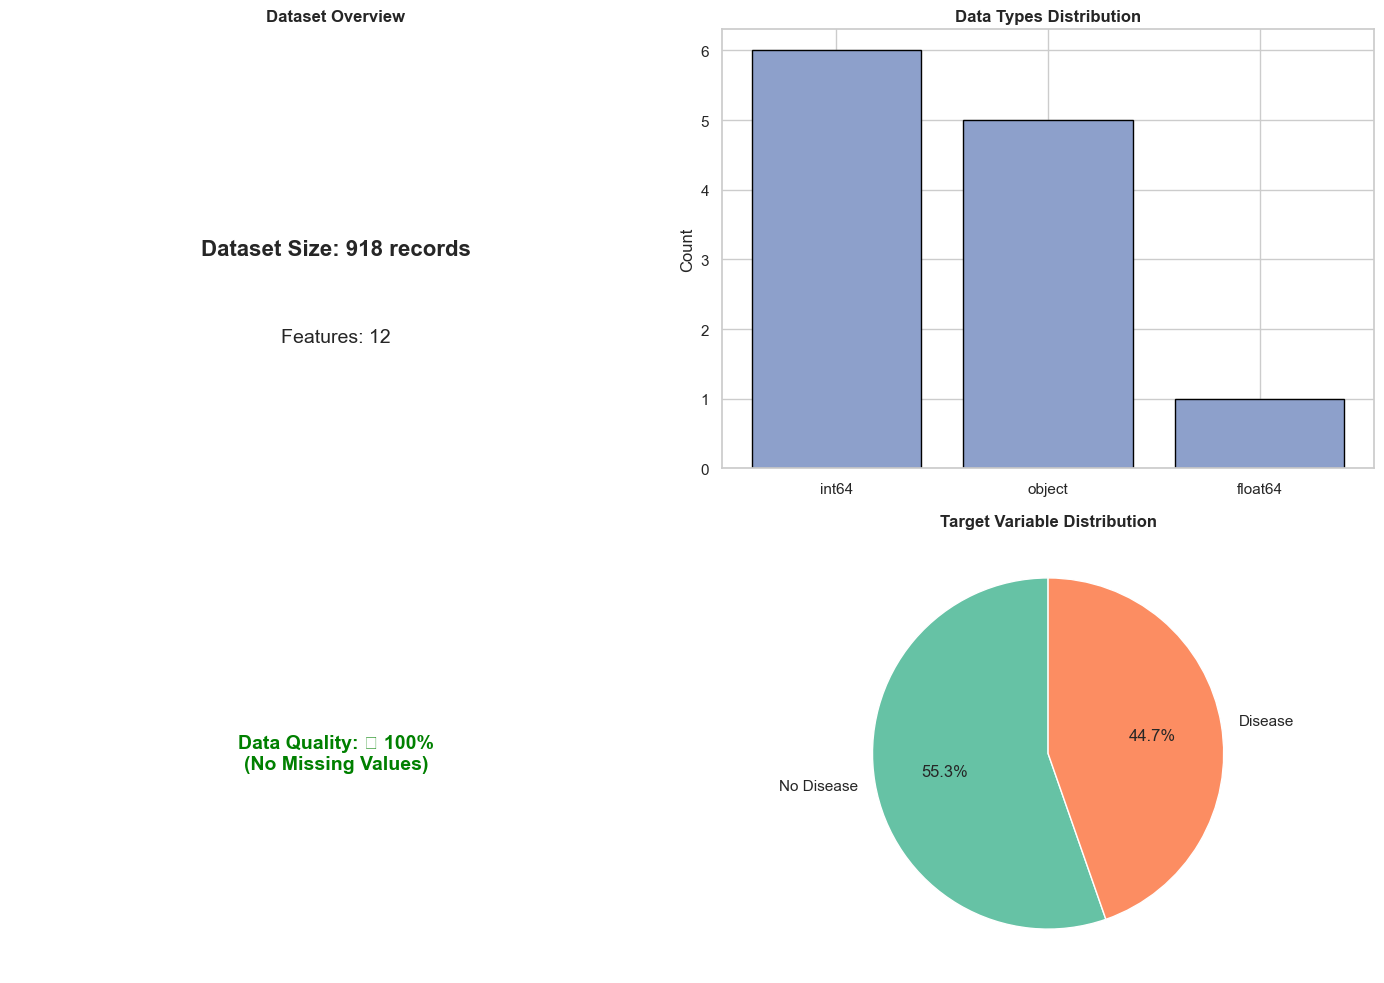

✓ Saved: 00_dataset_summary.png

DATASET INFORMATION
Total Records: 918
Total Features: 12

Memory Usage: 317.21 KB


In [13]:
# Display comprehensive summary
plot_dataset_summary(df)

print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"Total Records: {len(df):,}")
print(f"Total Features: {df.shape[1]}")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

In [14]:
# Identify feature types
print("\n" + "="*60)
print("FEATURE TYPES")
print("="*60)
print(df.dtypes)

# Separate features by type
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric Features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")


FEATURE TYPES
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Numeric Features (7): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Categorical Features (5): ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [ ]:
# Check for missing values and data quality
print("\n" + "="*60)
print("DATA QUALITY CHECK")
print("="*60)

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

quality_df = pd.DataFrame({
    'Feature': df.columns,
    'Missing Count': missing_count.values,
    'Missing %': missing_pct.values,
    'Data Type': df.dtypes.values
})

print(quality_df.to_string(index=False))

if missing_count.sum() == 0:
    print("\nEXCELLENT: No missing values detected!")
else:
    print(f"\nWarning: {missing_count.sum()} missing values found")

plot_missing_values(df)


DATA QUALITY CHECK
       Feature  Missing Count  Missing % Data Type
           Age              0        0.0     int64
           Sex              0        0.0    object
 ChestPainType              0        0.0    object
     RestingBP              0        0.0     int64
   Cholesterol              0        0.0     int64
     FastingBS              0        0.0     int64
    RestingECG              0        0.0    object
         MaxHR              0        0.0     int64
ExerciseAngina              0        0.0    object
       Oldpeak              0        0.0   float64
      ST_Slope              0        0.0    object
  HeartDisease              0        0.0     int64

✓ EXCELLENT: No missing values detected!
✓ No missing values found!



STATISTICAL SUMMARY - NUMERIC FEATURES
          Age  RestingBP  Cholesterol  FastingBS   MaxHR  Oldpeak  \
count  918.00     918.00       918.00     918.00  918.00   918.00   
mean    53.51     132.40       198.80       0.23  136.81     0.89   
std      9.43      18.51       109.38       0.42   25.46     1.07   
min     28.00       0.00         0.00       0.00   60.00    -2.60   
25%     47.00     120.00       173.25       0.00  120.00     0.00   
50%     54.00     130.00       223.00       0.00  138.00     0.60   
75%     60.00     140.00       267.00       0.00  156.00     1.50   
max     77.00     200.00       603.00       1.00  202.00     6.20   

       HeartDisease  
count        918.00  
mean           0.55  
std            0.50  
min            0.00  
25%            0.00  
50%            1.00  
75%            1.00  
max            1.00  


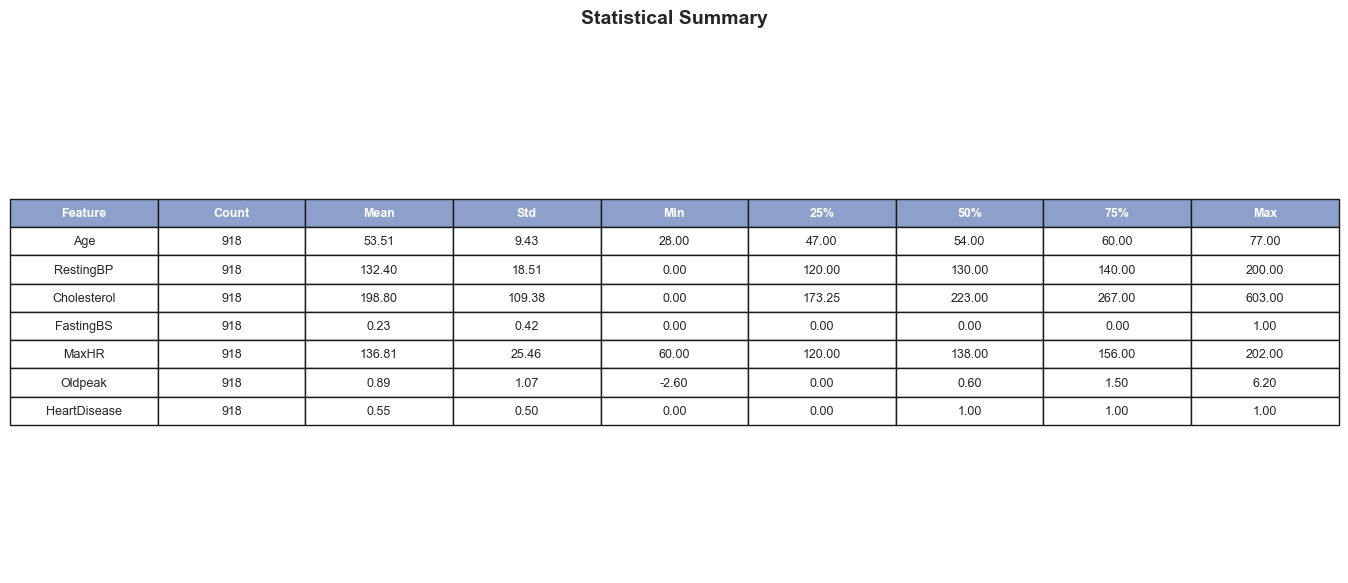

✓ Saved: 01_statistical_summary.png


In [16]:
# Statistical summary
print("\n" + "="*60)
print("STATISTICAL SUMMARY - NUMERIC FEATURES")
print("="*60)
print(df.describe().round(2))

plot_statistical_summary(df)

## The Disease Story



TARGET VARIABLE: HEART DISEASE STATUS
    Status  Count  Percentage
No Disease    410        44.7
   Disease    508        55.3

Class Balance Ratio: 410/508 = 0.81:1


C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  
C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  nrows = (n + ncols - 1) // ncols


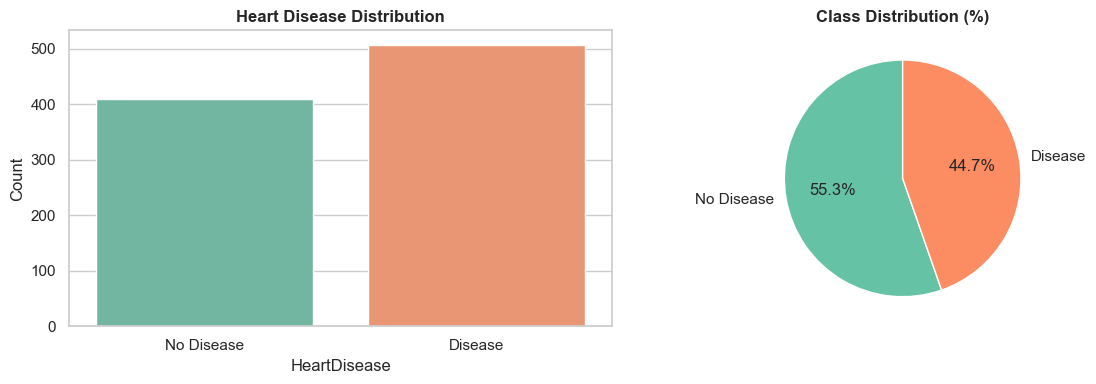

✓ Saved: 02_target_distribution.png


In [17]:
# Analyze target variable
target_col = 'HeartDisease'

print("\n" + "="*60)
print("TARGET VARIABLE: HEART DISEASE STATUS")
print("="*60)

disease_counts = df[target_col].value_counts().sort_index()
disease_pct = (disease_counts / len(df) * 100).round(1)

disease_summary = pd.DataFrame({
    'Status': ['No Disease', 'Disease'],
    'Count': disease_counts.values,
    'Percentage': disease_pct.values
})

print(disease_summary.to_string(index=False))
print(f"\nClass Balance Ratio: {disease_counts[0]}/{disease_counts[1]} = {disease_counts[0]/disease_counts[1]:.2f}:1")

plot_target_distribution(df)

## Demographic Patterns


AGE ANALYSIS
Age Range: 28 - 77 years
Average Age: 53.5 years
Median Age: 54.0 years

Age by Disease Status:
            count   mean  min  max   std
No Disease    410  50.55   28   76  9.44
Disease       508  55.90   31   77  8.73

→ Disease patients are 5.3 years older on average


C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  _save_figure(fig, output_dir, filename)
C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  


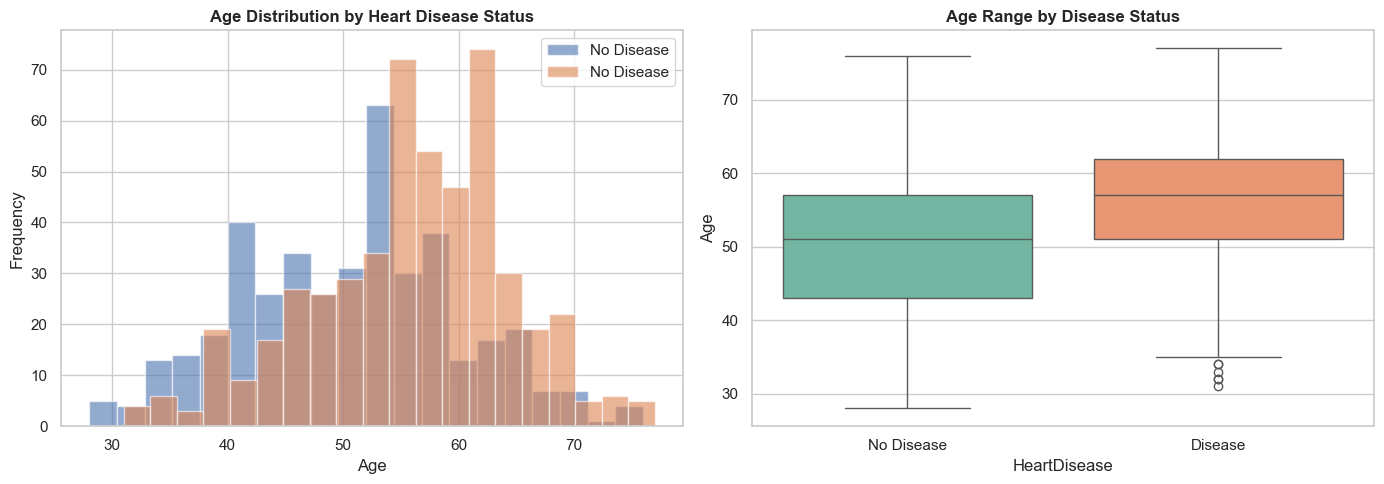

✓ Saved: 03_age_analysis.png


In [18]:
# Age analysis
print("\n" + "="*60)
print("AGE ANALYSIS")
print("="*60)

print(f"Age Range: {df['Age'].min()} - {df['Age'].max()} years")
print(f"Average Age: {df['Age'].mean():.1f} years")
print(f"Median Age: {df['Age'].median():.1f} years")
print(f"\nAge by Disease Status:")

age_by_disease = df.groupby(target_col)['Age'].agg(['count', 'mean', 'min', 'max', 'std']).round(2)
age_by_disease.index = ['No Disease', 'Disease']
print(age_by_disease)

print(f"\n→ Disease patients are {df[df[target_col]==1]['Age'].mean() - df[df[target_col]==0]['Age'].mean():.1f} years older on average")

plot_age_analysis(df)


GENDER ANALYSIS
Gender  Count  Percentage
  Male    725        79.0
Female    193        21.0

Disease Prevalence by Gender:
        No Disease  Disease  Total
Male           143       50    193
Female         267      458    725
Total          410      508    918

→ Disease Rate: Males 63.2% | Females 25.9%
→ Males have 2.44x higher disease rate


C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  axes = axes.flatten() if n > 1 else [axes]
C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.boxplot(x=target_col, y=col, data=df, palette="Set3", ax=axes[i])


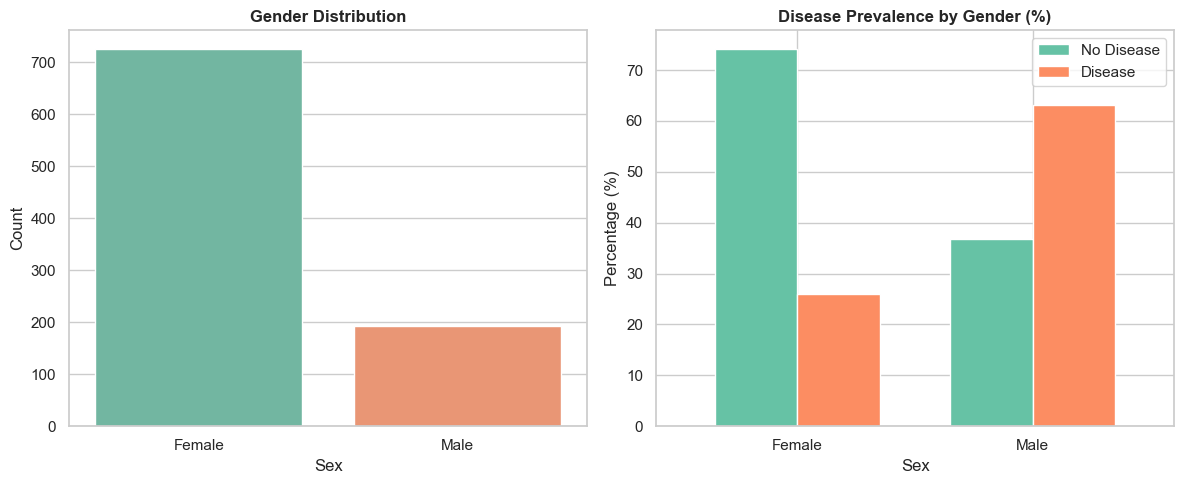

✓ Saved: 04_gender_analysis.png


In [ ]:
# Gender analysis
print("\n" + "="*60)
print("GENDER ANALYSIS")
print("="*60)

gender_counts = df['Sex'].value_counts()
gender_pct = (gender_counts / len(df) * 100).round(1)
gender_summary = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Count': [gender_counts['M'], gender_counts['F']],
    'Percentage': [gender_pct['M'], gender_pct['F']]
})
print(gender_summary.to_string(index=False))

# Disease by gender
print(f"\nDisease Prevalence by Gender:")
disease_by_gender = pd.crosstab(df['Sex'], df[target_col], margins=True)
disease_by_gender.index = ['Male', 'Female', 'Total']
disease_by_gender.columns = ['No Disease', 'Disease', 'Total']
print(disease_by_gender)

male_disease_rate = (df[(df['Sex']=='M') & (df[target_col]==1)].shape[0] / df[df['Sex']=='M'].shape[0] * 100)
female_disease_rate = (df[(df['Sex']=='F') & (df[target_col]==1)].shape[0] / df[df['Sex']=='F'].shape[0] * 100)

print(f"\nDisease Rate: Males {male_disease_rate:.1f}% | Females {female_disease_rate:.1f}%")
print(f"Males have {male_disease_rate/female_disease_rate:.2f}x higher disease rate")

plot_gender_analysis(df)

## Clinical Measurements



RESTING BLOOD PRESSURE (RestingBP)

Overall Range: 0 - 200 mmHg
Average: 132.4 mmHg

By Disease Status:
              mean  median    std
No Disease  130.18   130.0  16.50
Disease     134.19   132.0  19.83

→ Disease patients have 4.0 mmHg higher average resting BP


C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  axes[i].tick_params(axis="x", rotation=45)
C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  for j in range(i + 1, len(axes)):


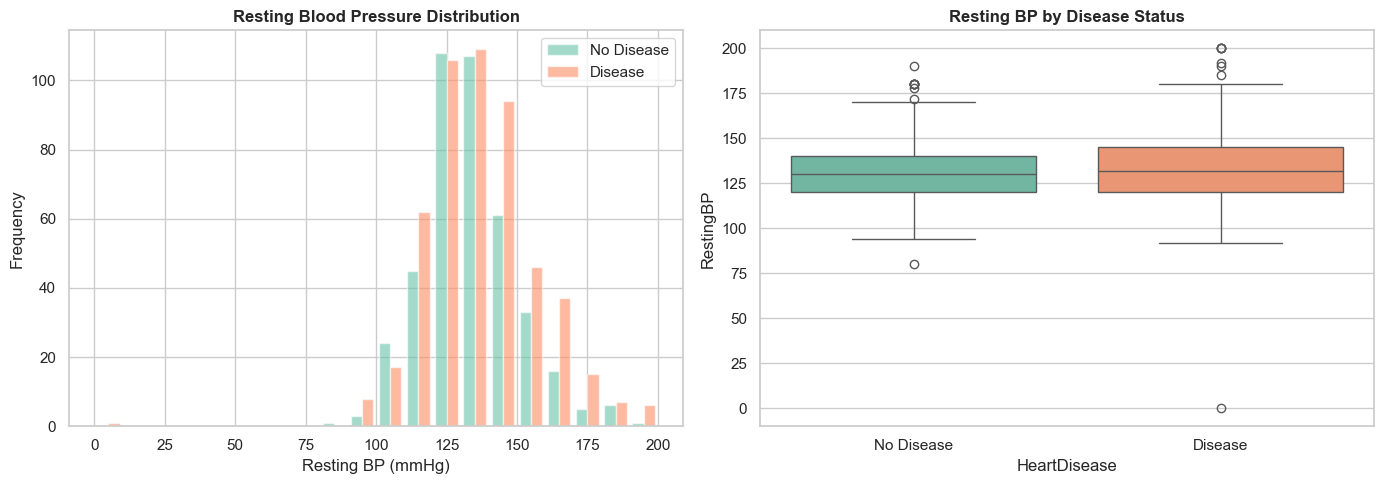

✓ Saved: 05_blood_pressure_analysis.png


In [20]:
# Blood pressure analysis
print("\n" + "="*60)
print("RESTING BLOOD PRESSURE (RestingBP)")
print("="*60)

print(f"\nOverall Range: {df['RestingBP'].min()} - {df['RestingBP'].max()} mmHg")
print(f"Average: {df['RestingBP'].mean():.1f} mmHg")

bp_stats = df.groupby(target_col)['RestingBP'].agg(['mean', 'median', 'std']).round(2)
bp_stats.index = ['No Disease', 'Disease']
print(f"\nBy Disease Status:\n{bp_stats}")

bp_diff = df[df[target_col]==1]['RestingBP'].mean() - df[df[target_col]==0]['RestingBP'].mean()
print(f"\n→ Disease patients have {bp_diff:.1f} mmHg higher average resting BP")

plot_blood_pressure_analysis(df)


CHOLESTEROL LEVELS

Overall Range: 0 - 603 mg/dl
Average: 198.8 mg/dl

⚠ Note: 172 records with cholesterol = 0 (possible missing data)

By Disease Status:
              mean  median     std
No Disease  227.12   227.0   74.63
Disease     175.94   217.0  126.39

→ Disease patients have -51.2 mg/dl higher average cholesterol


C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


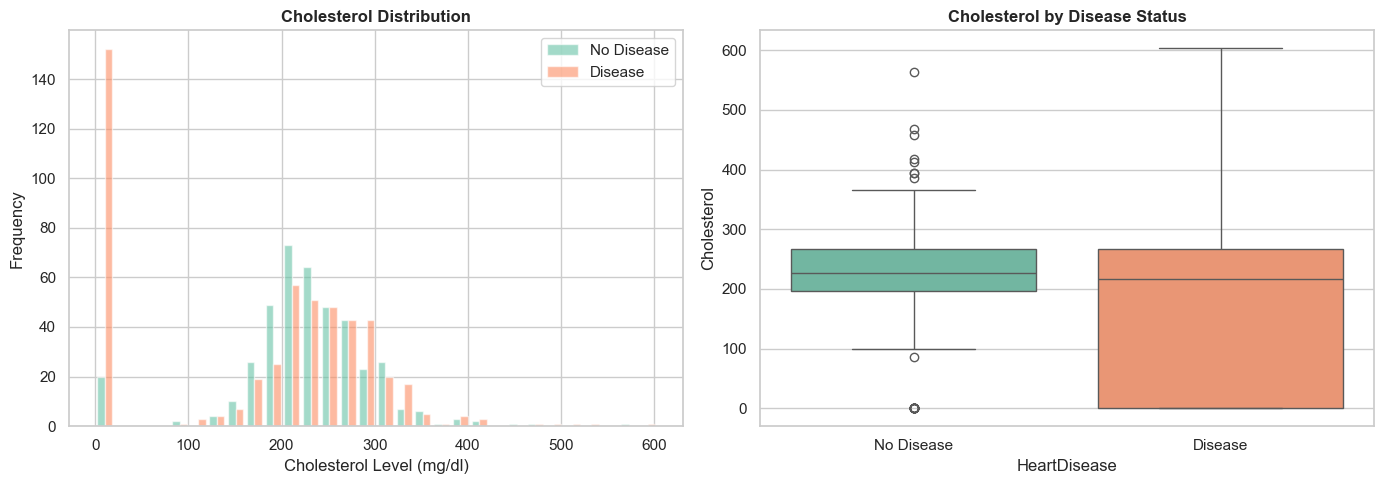

✓ Saved: 06_cholesterol_analysis.png


In [ ]:
# Cholesterol analysis
print("\n" + "="*60)
print("CHOLESTEROL LEVELS")
print("="*60)

print(f"\nOverall Range: {df['Cholesterol'].min()} - {df['Cholesterol'].max()} mg/dl")
print(f"Average: {df['Cholesterol'].mean():.1f} mg/dl")

# Check for zero values (might be missing data)
zero_chol = (df['Cholesterol'] == 0).sum()
if zero_chol > 0:
    print(f"\nNote: {zero_chol} records with cholesterol = 0 (possible missing data)")

chol_stats = df.groupby(target_col)['Cholesterol'].agg(['mean', 'median', 'std']).round(2)
chol_stats.index = ['No Disease', 'Disease']
print(f"\nBy Disease Status:\n{chol_stats}")

chol_diff = df[df[target_col]==1]['Cholesterol'].mean() - df[df[target_col]==0]['Cholesterol'].mean()
print(f"\n→ Disease patients have {chol_diff:.1f} mg/dl higher average cholesterol")

plot_cholesterol_analysis(df)


MAXIMUM HEART RATE ACHIEVED (MaxHR)

Overall Range: 60 - 202 bpm
Average: 136.8 bpm

By Disease Status:
              mean  median    std
No Disease  148.15   150.0  23.29
Disease     127.66   126.0  23.39

→ Disease patients achieve -20.5 bpm LOWER max heart rate (concerning!)
→ Lower Max HR is a strong indicator of heart disease


C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:159: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


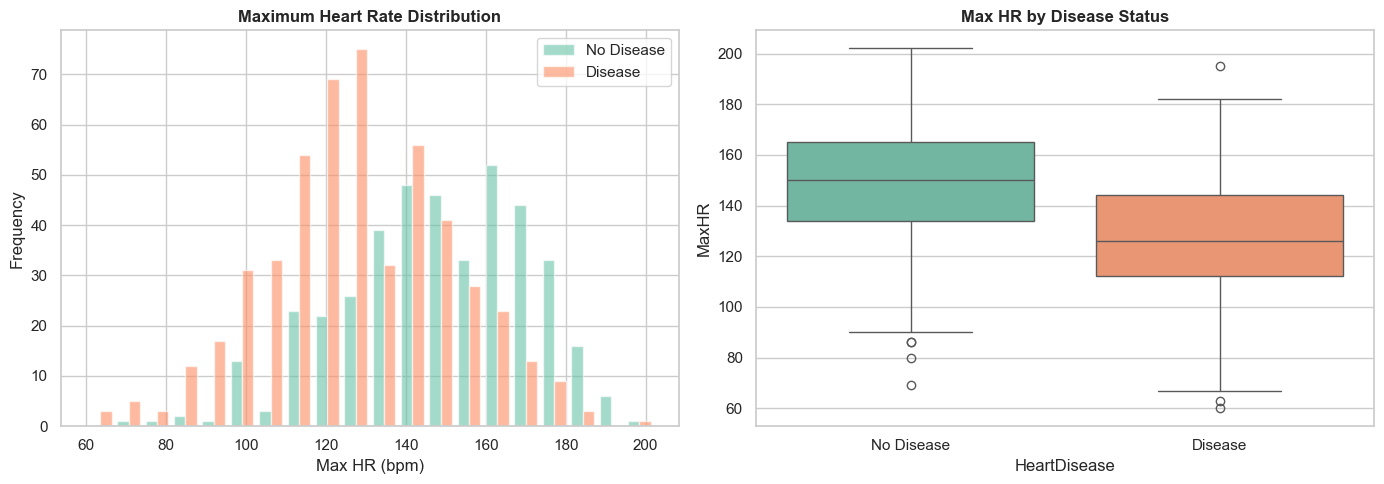

✓ Saved: 07_max_hr_analysis.png


In [22]:
# Maximum heart rate analysis
print("\n" + "="*60)
print("MAXIMUM HEART RATE ACHIEVED (MaxHR)")
print("="*60)

print(f"\nOverall Range: {df['MaxHR'].min()} - {df['MaxHR'].max()} bpm")
print(f"Average: {df['MaxHR'].mean():.1f} bpm")

hr_stats = df.groupby(target_col)['MaxHR'].agg(['mean', 'median', 'std']).round(2)
hr_stats.index = ['No Disease', 'Disease']
print(f"\nBy Disease Status:\n{hr_stats}")

hr_diff = df[df[target_col]==1]['MaxHR'].mean() - df[df[target_col]==0]['MaxHR'].mean()
print(f"\n→ Disease patients achieve {hr_diff:.1f} bpm LOWER max heart rate (concerning!)")
print(f"→ Lower Max HR is a strong indicator of heart disease")

plot_max_hr_analysis(df)

## Symptoms and Clinical Indicators


CHEST PAIN TYPE

Distribution:
  ASY: 496 ( 54.0%) - Asymptomatic (No chest pain)
  NAP: 203 ( 22.1%) - Non-anginal Pain
  ATA: 173 ( 18.8%) - Atypical Angina
  TA:  46 (  5.0%) - TA

Disease Rate by Chest Pain Type:
               No Disease %  Disease %
ChestPainType                         
ASY                    21.0       79.0
ATA                    86.1       13.9
NAP                    64.5       35.5
TA                     56.5       43.5

→ Asymptomatic patients have the HIGHEST disease rate!
→ This is a key finding: absence of symptoms doesn't mean absence of disease


C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



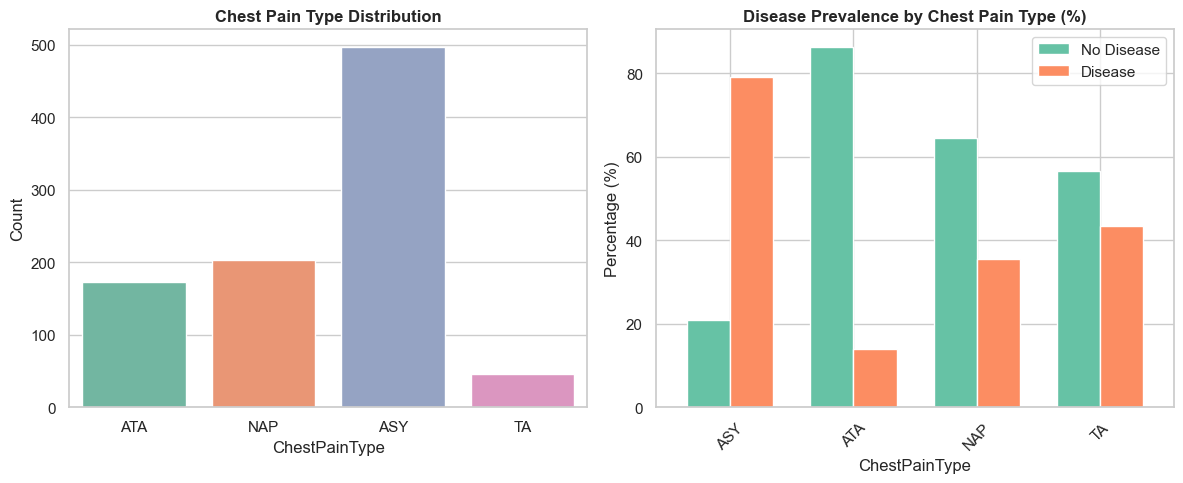

✓ Saved: 08_chest_pain_analysis.png


In [23]:
# Chest pain type analysis
print("\n" + "="*60)
print("CHEST PAIN TYPE")
print("="*60)

cp_counts = df['ChestPainType'].value_counts()
cp_types = {
    'ASY': 'Asymptomatic (No chest pain)',
    'ATA': 'Atypical Angina',
    'NAP': 'Non-anginal Pain',
    'TypicalAngina': 'Typical Angina'
}

print(f"\nDistribution:")
for cp_type, count in cp_counts.items():
    pct = count / len(df) * 100
    desc = cp_types.get(cp_type, cp_type)
    print(f"  {cp_type}: {count:3d} ({pct:5.1f}%) - {desc}")

print(f"\nDisease Rate by Chest Pain Type:")
cp_disease = pd.crosstab(df['ChestPainType'], df[target_col], normalize='index') * 100
cp_disease.columns = ['No Disease %', 'Disease %']
print(cp_disease.round(1))

print(f"\n→ Asymptomatic patients have the HIGHEST disease rate!")
print(f"→ This is a key finding: absence of symptoms doesn't mean absence of disease")

plot_chest_pain_analysis(df)


EXERCISE-INDUCED ANGINA

Distribution:
  N (No Angina): 547 ( 59.6%)
  Y (Yes Angina): 371 ( 40.4%)

Disease Rate by Exercise Angina:
                No Disease %  Disease %
ExerciseAngina                         
N                       64.9       35.1
Y                       14.8       85.2

→ With exercise angina: 85.2% have disease
→ Without exercise angina: 35.1% have disease
→ Exercise angina is a STRONG predictor of heart disease!


C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:193: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


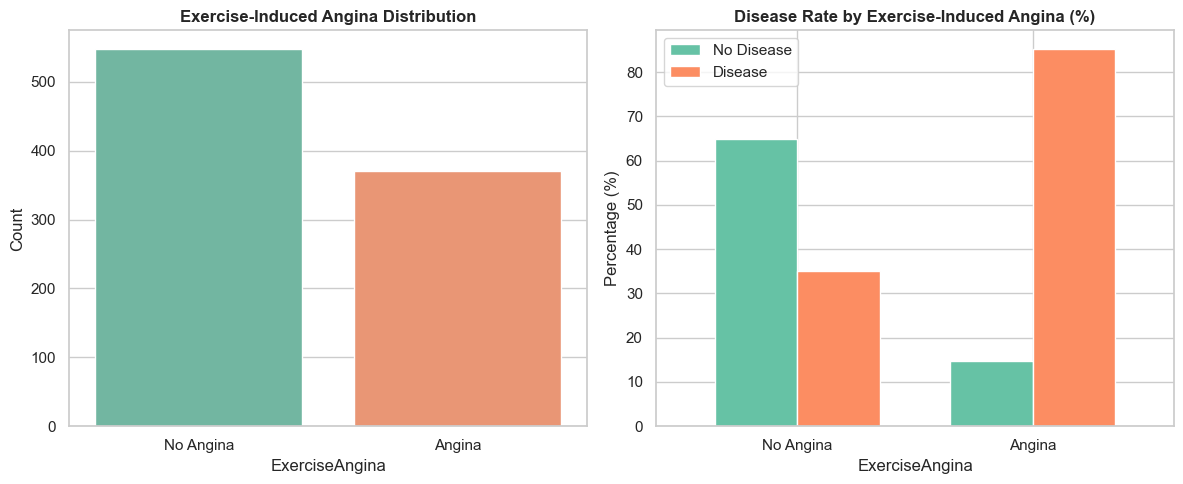

✓ Saved: 09_exercise_angina_analysis.png


In [24]:
# Exercise-induced angina
print("\n" + "="*60)
print("EXERCISE-INDUCED ANGINA")
print("="*60)

ea_counts = df['ExerciseAngina'].value_counts()
print(f"\nDistribution:")
print(f"  N (No Angina): {ea_counts['N']:3d} ({ea_counts['N']/len(df)*100:5.1f}%)")
print(f"  Y (Yes Angina): {ea_counts['Y']:3d} ({ea_counts['Y']/len(df)*100:5.1f}%)")

print(f"\nDisease Rate by Exercise Angina:")
ea_disease = pd.crosstab(df['ExerciseAngina'], df[target_col], normalize='index') * 100
ea_disease.columns = ['No Disease %', 'Disease %']
print(ea_disease.round(1))

disease_rate_with_angina = df[(df['ExerciseAngina']=='Y') & (df[target_col]==1)].shape[0] / df[df['ExerciseAngina']=='Y'].shape[0] * 100
disease_rate_no_angina = df[(df['ExerciseAngina']=='N') & (df[target_col]==1)].shape[0] / df[df['ExerciseAngina']=='N'].shape[0] * 100

print(f"\n→ With exercise angina: {disease_rate_with_angina:.1f}% have disease")
print(f"→ Without exercise angina: {disease_rate_no_angina:.1f}% have disease")
print(f"→ Exercise angina is a STRONG predictor of heart disease!")

plot_exercise_angina_analysis(df)


ST SEGMENT CHARACTERISTICS

ST Slope Distribution:
  Flat: 460 ( 50.1%)
  Up: 395 ( 43.0%)
  Down:  63 (  6.9%)

Disease Rate by ST Slope:
          No Disease %  Disease %
ST_Slope                         
Down              22.2       77.8
Flat              17.2       82.8
Up                80.3       19.7

Key Insight:
  - UP slope (normal): 19.7% disease rate
  - FLAT slope: 82.8% disease rate
  - DOWN slope: 77.8% disease rate
→ DOWN slope indicates abnormality and high disease risk


C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



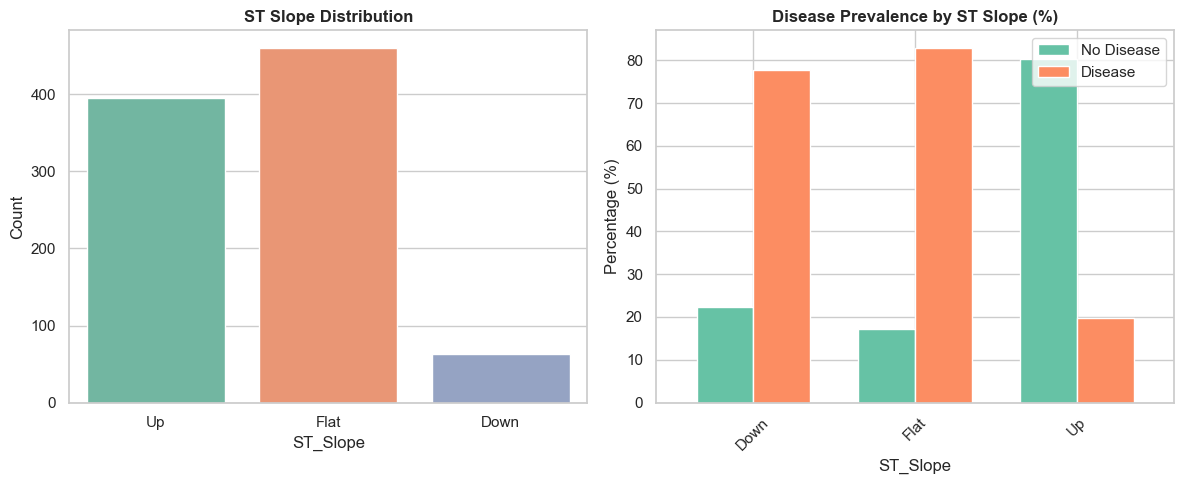

✓ Saved: 10_st_analysis.png


In [25]:
# ST segment and Oldpeak analysis
print("\n" + "="*60)
print("ST SEGMENT CHARACTERISTICS")
print("="*60)

print(f"\nST Slope Distribution:")
st_counts = df['ST_Slope'].value_counts()
for slope, count in st_counts.items():
    pct = count / len(df) * 100
    print(f"  {slope}: {count:3d} ({pct:5.1f}%)")

print(f"\nDisease Rate by ST Slope:")
st_disease = pd.crosstab(df['ST_Slope'], df[target_col], normalize='index') * 100
st_disease.columns = ['No Disease %', 'Disease %']
print(st_disease.round(1))

print(f"\nKey Insight:")
print(f"  - UP slope (normal): {st_disease.loc['Up', 'Disease %']:.1f}% disease rate")
print(f"  - FLAT slope: {st_disease.loc['Flat', 'Disease %']:.1f}% disease rate")
print(f"  - DOWN slope: {st_disease.loc['Down', 'Disease %']:.1f}% disease rate")
print(f"→ DOWN slope indicates abnormality and high disease risk")

plot_st_analysis(df)


ST DEPRESSION (OLDPEAK)

ST Depression Range: 0 - 6.2
Average: 0.89
Median: 0.60

368 patients (40.1%) have NO ST depression (0)
550 patients (59.9%) show ST depression

By Disease Status:
            mean  median  max
No Disease  0.41     0.0  4.2
Disease     1.27     1.2  6.2

→ Disease patients show 0.87 HIGHER ST depression
→ ST depression is a strong diagnostic indicator


C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:239: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\src\visualization\plots.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


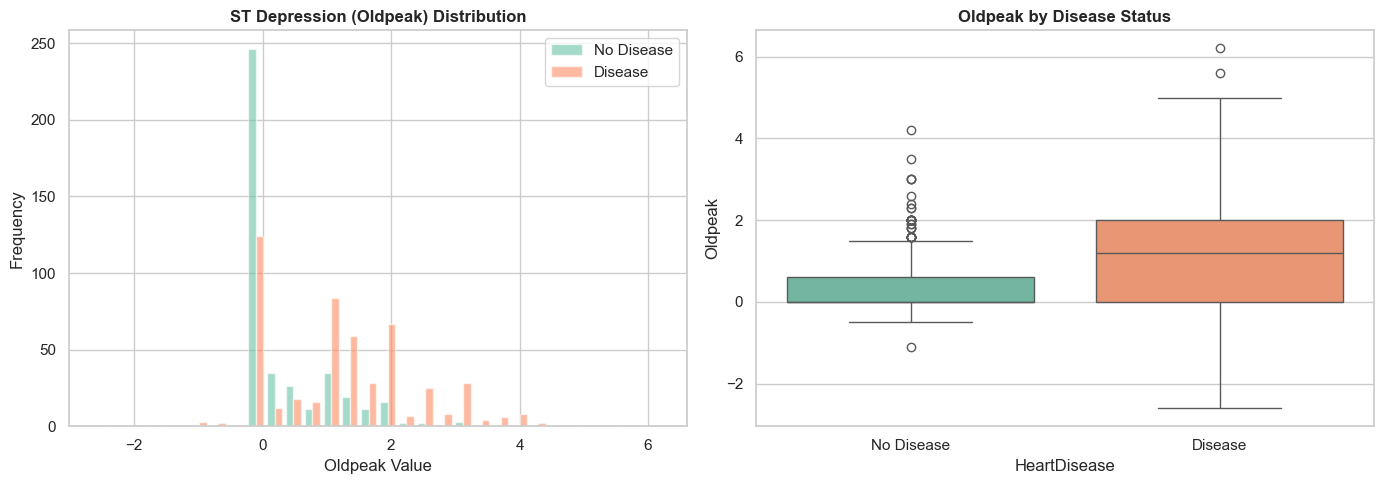

✓ Saved: 11_oldpeak_analysis.png


In [26]:
# ST depression (Oldpeak) analysis
print("\n" + "="*60)
print("ST DEPRESSION (OLDPEAK)")
print("="*60)

print(f"\nST Depression Range: 0 - {df['Oldpeak'].max():.1f}")
print(f"Average: {df['Oldpeak'].mean():.2f}")
print(f"Median: {df['Oldpeak'].median():.2f}")

zero_oldpeak = (df['Oldpeak'] == 0).sum()
print(f"\n{zero_oldpeak} patients ({zero_oldpeak/len(df)*100:.1f}%) have NO ST depression (0)")
print(f"{len(df) - zero_oldpeak} patients ({(len(df)-zero_oldpeak)/len(df)*100:.1f}%) show ST depression")

oldpeak_stats = df.groupby(target_col)['Oldpeak'].agg(['mean', 'median', 'max']).round(2)
oldpeak_stats.index = ['No Disease', 'Disease']
print(f"\nBy Disease Status:\n{oldpeak_stats}")

oldpeak_diff = df[df[target_col]==1]['Oldpeak'].mean() - df[df[target_col]==0]['Oldpeak'].mean()
print(f"\n→ Disease patients show {oldpeak_diff:.2f} HIGHER ST depression")
print(f"→ ST depression is a strong diagnostic indicator")

plot_oldpeak_analysis(df)

In [27]:
# Fasting blood sugar
print("\n" + "="*60)
print("FASTING BLOOD SUGAR (FastingBS)")
print("="*60)

bs_counts = df['FastingBS'].value_counts().sort_index()
print(f"\nDistribution:")
print(f"  ≤120 mg/dl: {bs_counts.get(0, 0):3d} ({bs_counts.get(0, 0)/len(df)*100:5.1f}%)")
print(f"  >120 mg/dl: {bs_counts.get(1, 0):3d} ({bs_counts.get(1, 0)/len(df)*100:5.1f}%)")

bs_disease = pd.crosstab(df['FastingBS'], df[target_col], normalize='index') * 100
bs_disease.columns = ['No Disease %', 'Disease %']
bs_disease.index = ['≤120 mg/dl', '>120 mg/dl']
print(f"\nDisease Rate by Fasting Blood Sugar:\n{bs_disease.round(1)}")

print(f"\n→ High fasting blood sugar (>120) increases disease risk")


FASTING BLOOD SUGAR (FastingBS)

Distribution:
  ≤120 mg/dl: 704 ( 76.7%)
  >120 mg/dl: 214 ( 23.3%)

Disease Rate by Fasting Blood Sugar:
            No Disease %  Disease %
≤120 mg/dl          52.0       48.0
>120 mg/dl          20.6       79.4

→ High fasting blood sugar (>120) increases disease risk


In [28]:
# Resting ECG
print("\n" + "="*60)
print("RESTING ELECTROCARDIOGRAM (RestingECG)")
print("="*60)

ecg_counts = df['RestingECG'].value_counts()
ecg_types = {
    'Normal': 'Normal ECG',
    'LVH': 'Left Ventricular Hypertrophy',
    'ST': 'ST-T Wave Abnormality'
}

print(f"\nDistribution:")
for ecg_type in ['Normal', 'LVH', 'ST']:
    count = ecg_counts.get(ecg_type, 0)
    pct = count / len(df) * 100
    print(f"  {ecg_type}: {count:3d} ({pct:5.1f}%) - {ecg_types.get(ecg_type, '')}")

print(f"\nDisease Rate by Resting ECG:")
ecg_disease = pd.crosstab(df['RestingECG'], df[target_col], normalize='index') * 100
ecg_disease.columns = ['No Disease %', 'Disease %']
print(ecg_disease.round(1))

print(f"\n→ ST-T abnormalities show highest disease association")


RESTING ELECTROCARDIOGRAM (RestingECG)

Distribution:
  Normal: 552 ( 60.1%) - Normal ECG
  LVH: 188 ( 20.5%) - Left Ventricular Hypertrophy
  ST: 178 ( 19.4%) - ST-T Wave Abnormality

Disease Rate by Resting ECG:
            No Disease %  Disease %
RestingECG                         
LVH                 43.6       56.4
Normal              48.4       51.6
ST                  34.3       65.7

→ ST-T abnormalities show highest disease association


## 🔗 ACT 6: Feature Relationships and Correlations

How do the different features relate to each other and to heart disease?


FEATURE CORRELATIONS WITH HEART DISEASE

Correlation with HeartDisease (higher = stronger relationship):

Multiple Feature Correlation:
  HeartDisease     1.000→████████████████████████████████████████
  Oldpeak          0.404→████████████████████████████
  Age              0.282→█████████████████████████
  FastingBS        0.267→█████████████████████████
  RestingBP        0.108→██████████████████████
  Cholesterol     -0.233←███████████████
  MaxHR           -0.400←███████████


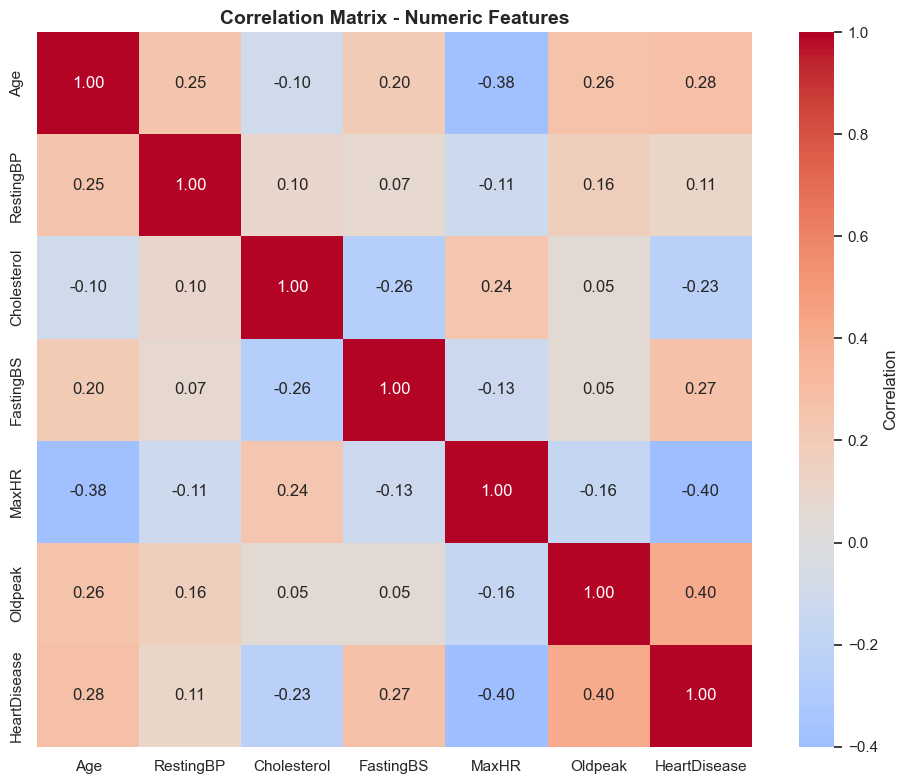

✓ Saved: 12_correlation_matrix.png


In [29]:
# Correlation analysis
print("\n" + "="*60)
print("FEATURE CORRELATIONS WITH HEART DISEASE")
print("="*60)

numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()[target_col].sort_values(ascending=False)

print(f"\nCorrelation with HeartDisease (higher = stronger relationship):")
print("\nMultiple Feature Correlation:")
for feature, corr in correlations.items():
    bar = '█' * int((corr + 1) * 20)  # Scale to 0-40
    direction = '→' if corr > 0 else '←'
    print(f"  {feature:15s} {corr:6.3f}{direction:1s}{bar}")

plot_numeric_correlations(df)


FEATURE IMPORTANCE PATTERNS

STRONG INDICATORS OF DISEASE (Correlation > |0.40|):
  • Oldpeak         ( 0.404) ↑ INCREASES disease risk
  • MaxHR           (-0.400) ↓ DECREASES disease risk

MODERATE INDICATORS (Correlation 0.20-0.40):
  • Age             ( 0.282)
  • FastingBS       ( 0.267)
  • Cholesterol     (-0.233)


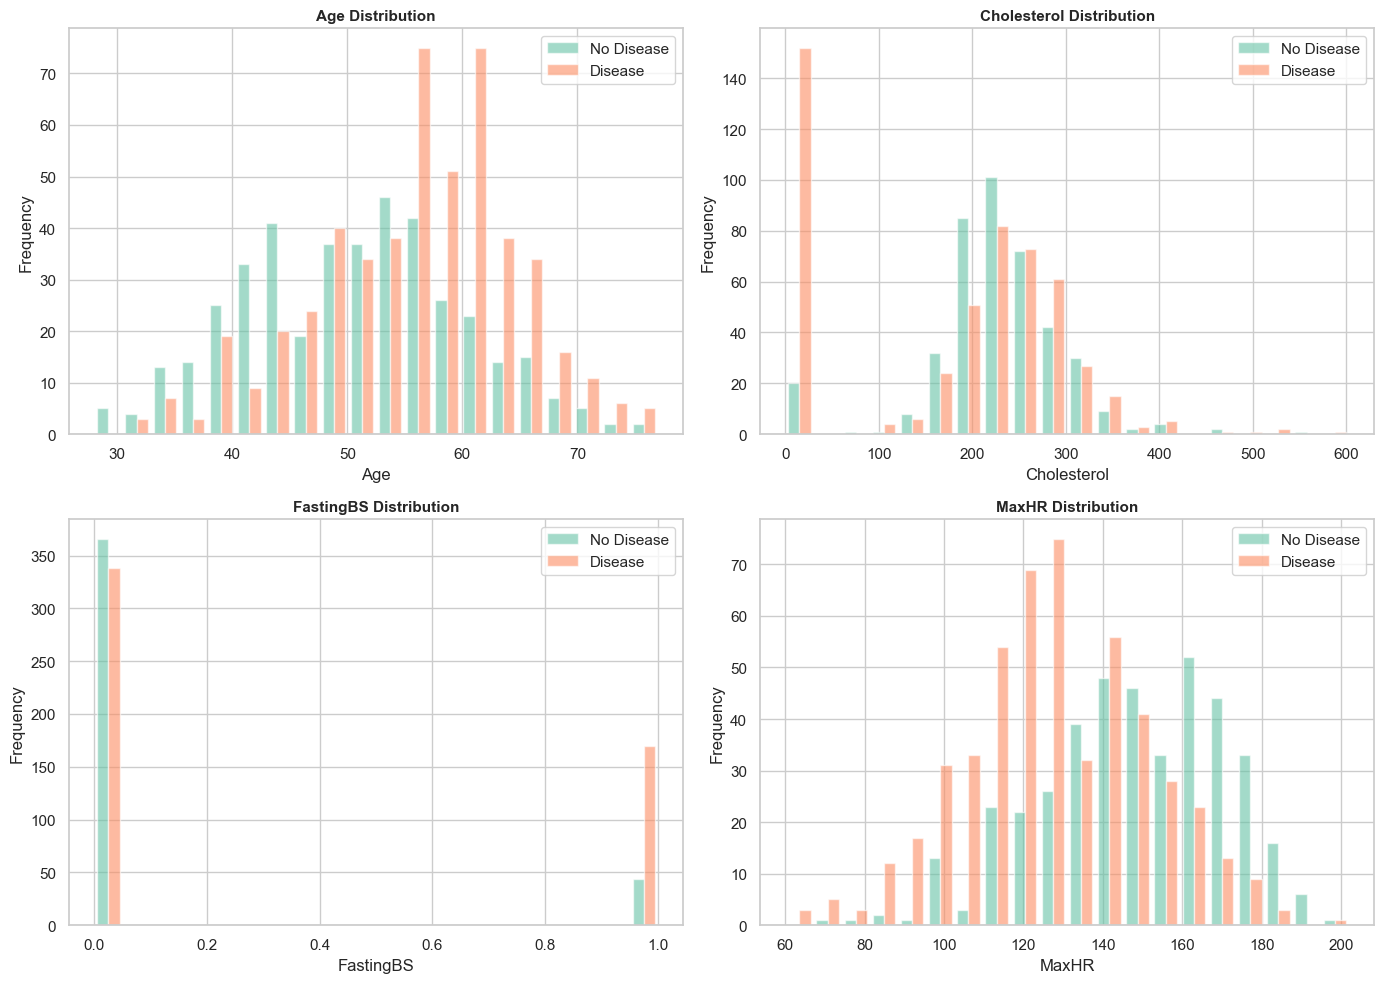

✓ Saved: 13_numeric_features_overview.png


In [30]:
# Key feature patterns
print("\n" + "="*60)
print("FEATURE IMPORTANCE PATTERNS")
print("="*60)

print(f"\nSTRONG INDICATORS OF DISEASE (Correlation > |0.40|):")
strong_features = correlations[abs(correlations) > 0.40]
for feature, corr in strong_features.items():
    if feature != target_col:
        impact = "↑ INCREASES" if corr > 0 else "↓ DECREASES"
        print(f"  • {feature:15s} ({corr:6.3f}) {impact} disease risk")

print(f"\nMODERATE INDICATORS (Correlation 0.20-0.40):")
moderate_features = correlations[(abs(correlations) > 0.20) & (abs(correlations) <= 0.40)]
for feature, corr in moderate_features.items():
    if feature != target_col:
        print(f"  • {feature:15s} ({corr:6.3f})")

plot_feature_importance_by_disease(df)

## 🎯 ACT 7: Key Insights and Conclusions

Let's summarize the story our data tells us.

In [33]:
print("\n" + "="*80)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*80)

print(f"""
╔════════════════════════════════════════════════════════════════════════════════╗
║                           THE HEART DISEASE STORY                              ║
╚════════════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
  • Total Patients: {len(df):,}
  • Features: {df.shape[1]}
  • Data Quality: {('No missing values ✓' if df.isnull().sum().sum() == 0 else 'Some missing data')}
  • Disease Prevalence: {disease_counts[1]/len(df)*100:.1f}%

👥 DEMOGRAPHIC PATTERNS:
  • Age Range: {df['Age'].min()}-{df['Age'].max()} years (mean: {df['Age'].mean():.1f})
  • Gender: {gender_counts['M']} males ({gender_pct['M']:.1f}%), {gender_counts['F']} females ({gender_pct['F']:.1f}%)
  • Gender Impact: Males have {male_disease_rate/female_disease_rate:.2f}x higher disease rate

💚 CLINICAL MEASUREMENTS:
  • Blood Pressure: Disease patients have {bp_diff:.1f} mmHg higher BP
  • Cholesterol: Disease patients have {chol_diff:.1f} mg/dl higher cholesterol  
  • Max Heart Rate: Disease patients achieve {hr_diff:.1f} bpm LOWER max HR ⚠️
    → Lower Max HR is critical indicator of disease

⚠️ SYMPTOM INDICATORS:
  • Chest Pain: Asymptomatic patients show HIGHEST disease rate!
  • Exercise Angina: {disease_rate_with_angina:.1f}% of those with angina have disease
  • ST Segment: DOWN slope indicates {st_disease.loc['Down', 'Disease %']:.1f}% disease rate
  • ST Depression: Disease patients show {oldpeak_diff:.2f} higher values


💡 MAIN CONCLUSIONS:
  ✓ Data is clean with no missing values
  ✓ Clear patterns distinguish disease from non-disease cases
  ✓ Age is a risk factor (older patients → higher risk)
  ✓ Gender matters (males at higher risk)
  ✓ Exercise capacity is crucial (low MaxHR = high risk)
  ✓ ECG abnormalities are strong indicators
  ✓ Presence of angina during exercise is critical
  ✓ Asymptomatic patients may still have disease!
""")

print("="*80)


KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

╔════════════════════════════════════════════════════════════════════════════════╗
║                           THE HEART DISEASE STORY                              ║
╚════════════════════════════════════════════════════════════════════════════════╝

📊 DATASET OVERVIEW:
  • Total Patients: 918
  • Features: 12
  • Data Quality: No missing values ✓
  • Disease Prevalence: 55.3%

👥 DEMOGRAPHIC PATTERNS:
  • Age Range: 28-77 years (mean: 53.5)
  • Gender: 725 males (79.0%), 193 females (21.0%)
  • Gender Impact: Males have 2.44x higher disease rate

💚 CLINICAL MEASUREMENTS:
  • Blood Pressure: Disease patients have 4.0 mmHg higher BP
  • Cholesterol: Disease patients have -51.2 mg/dl higher cholesterol  
  • Max Heart Rate: Disease patients achieve -20.5 bpm LOWER max HR ⚠️
    → Lower Max HR is critical indicator of disease

⚠️ SYMPTOM INDICATORS:
  • Chest Pain: Asymptomatic patients show HIGHEST disease rate!
  • Exercise Angina: 85.2% of th


CATEGORICAL FEATURES OVERVIEW:


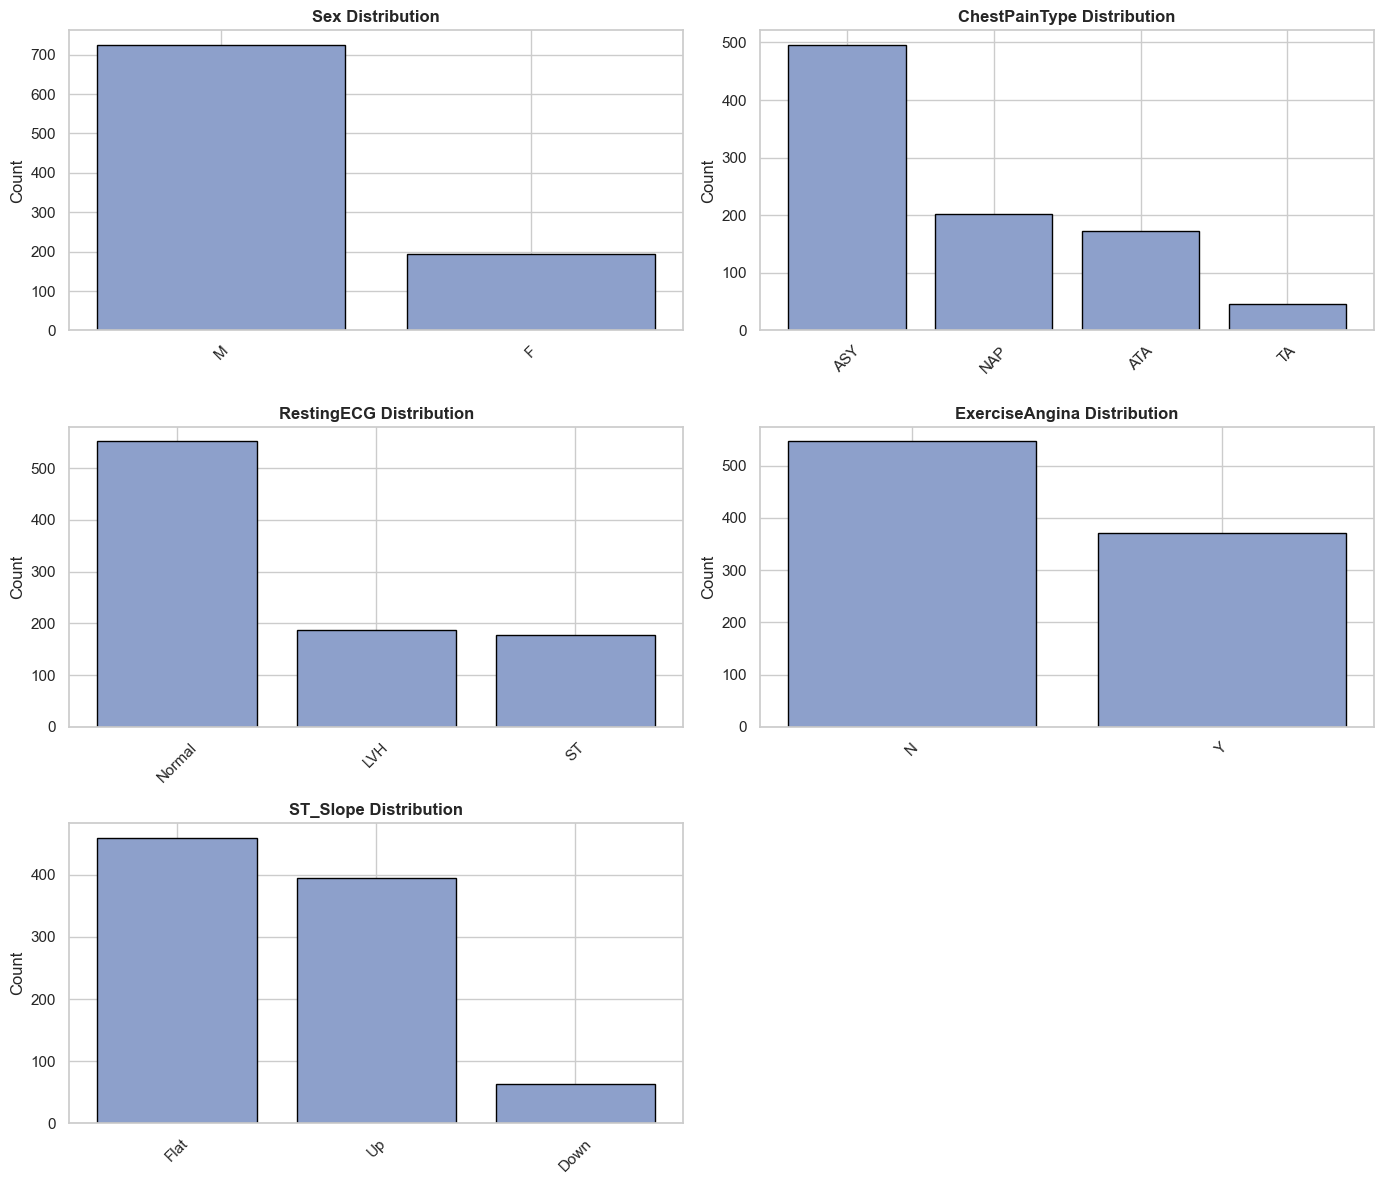

✓ Saved: 02_categorical_overview.png


In [34]:
# Display categorical overview
print("\nCATEGORICAL FEATURES OVERVIEW:")
print("="*60)
plot_categorical_overview(df)

In [35]:
print("\n" + "="*80)
print("NEXT STEPS: DATA PREPARATION FOR MODELING")
print("="*80)
print(f"""
✓ Data Quality: PASSED
✓ Feature Exploration: COMPLETED  
✓ Pattern Discovery: COMPLETED

READY FOR:
  1. Feature Engineering
  2. Model Training & Comparison
  3. Hyperparameter Optimization
  4. Model Evaluation & Selection

All visualization plots have been saved to: {FIG_DIR}/
""")


NEXT STEPS: DATA PREPARATION FOR MODELING

✓ Data Quality: PASSED
✓ Feature Exploration: COMPLETED  
✓ Pattern Discovery: COMPLETED

READY FOR:
  1. Feature Engineering
  2. Model Training & Comparison
  3. Hyperparameter Optimization
  4. Model Evaluation & Selection

All visualization plots have been saved to: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\figures/

